### This notebook demonstrates gradient descent for analytically closed form functions.

Let $u(x,y,z)$ be a scalar function of three variables.

$du = \frac{\partial u}{\partial x}dx + \frac{\partial u}{\partial y}dy + \frac{\partial u}{\partial z}dz$

That can be rewritten as
$du = \left(\frac{\partial u}{\partial x} \hat{x}, \frac{\partial u}{\partial y} \hat{y}, \frac{\partial u}{\partial z} \hat{z}\right) \cdot \left(dx \hat{x}, dy \hat{y}, dz \hat{z}\right).$

The gradient of $u$ is defined as
$\nabla u = \left(\frac{\partial u}{\partial x}, \frac{\partial u}{\partial y}, \frac{\partial u}{\partial z}\right)^T.$

Therefore:

$du = \nabla u^T \cdot \left(dx \hat{x}, dy \hat{y}, dz \hat{z}\right).$

Let us rewrite the dot product  in abstract form:

$du = |\nabla u| |d\mathbf{r}| \cos\theta,$

where $\theta$ is the angle between $\nabla u$ and $d\mathbf{r}$.

As we can see, for a fixed distance $|d\mathbf{r}|$, the differential $du$ is maximized when $\cos\theta = 1$, i.e., when $d\mathbf{r}$ is in the direction of $\nabla u$.

This implies that the gradient $\nabla u$ points in the direction of the steepest ascent of the function $u(x,y,z)$.



In [1]:
import math

In [2]:
def L(x,y):
    return ((y-2)**2)+((x+5)**2)
    # return math.exp(x) + math.exp(y) 

def dldx(x,y):
    return 2*(x+5) #math.exp(x)

def dldy(x,y):
    return 2*(y-2) #math.exp(y)
 


In [3]:
x = -15 # some random starting point
y = 10 # some random starting point
eta = 0.05 # learning rate


In [4]:
init = 1000
L_values = []
# for _ in range(20):
while abs(L(x,y)-init) > 0.00001:  
    init = L(x,y)
    xnew = x - eta*dldx(x,y)
    ynew = y - eta*dldy(x,y)
    x = xnew
    y = ynew
    print(f"x: {x:.2f}, y: {y:.2f}, L(x,y): {L(x,y):.2f}")
    L_values.append(L(x,y))


x: -14.00, y: 9.20, L(x,y): 132.84
x: -13.10, y: 8.48, L(x,y): 107.60
x: -12.29, y: 7.83, L(x,y): 87.16
x: -11.56, y: 7.25, L(x,y): 70.60
x: -10.90, y: 6.72, L(x,y): 57.18
x: -10.31, y: 6.25, L(x,y): 46.32
x: -9.78, y: 5.83, L(x,y): 37.52
x: -9.30, y: 5.44, L(x,y): 30.39
x: -8.87, y: 5.10, L(x,y): 24.62
x: -8.49, y: 4.79, L(x,y): 19.94
x: -8.14, y: 4.51, L(x,y): 16.15
x: -7.82, y: 4.26, L(x,y): 13.08
x: -7.54, y: 4.03, L(x,y): 10.60
x: -7.29, y: 3.83, L(x,y): 8.58
x: -7.06, y: 3.65, L(x,y): 6.95
x: -6.85, y: 3.48, L(x,y): 5.63
x: -6.67, y: 3.33, L(x,y): 4.56
x: -6.50, y: 3.20, L(x,y): 3.69
x: -6.35, y: 3.08, L(x,y): 2.99
x: -6.22, y: 2.97, L(x,y): 2.42
x: -6.09, y: 2.88, L(x,y): 1.96
x: -5.98, y: 2.79, L(x,y): 1.59
x: -5.89, y: 2.71, L(x,y): 1.29
x: -5.80, y: 2.64, L(x,y): 1.04
x: -5.72, y: 2.57, L(x,y): 0.85
x: -5.65, y: 2.52, L(x,y): 0.68
x: -5.58, y: 2.47, L(x,y): 0.55
x: -5.52, y: 2.42, L(x,y): 0.45
x: -5.47, y: 2.38, L(x,y): 0.36
x: -5.42, y: 2.34, L(x,y): 0.29
x: -5.38, y: 2.31, 

For $X=(x_1,\ldots,x_n)$ and scalar loss $L=L(X)$,

$
dL=\sum_{i=1}^{n}\frac{\partial L}{\partial x_i}\,dx_i
   =\nabla_X L^{T}dX.
$

where

$
\nabla_XL=
\begin{bmatrix}
\frac{\partial L}{\partial x_1}\\
\vdots\\
\frac{\partial L}{\partial x_n}
\end{bmatrix},
\qquad
dX=
\begin{bmatrix}
dx_1\\
\vdots\\
dx_n
\end{bmatrix}.
$


Thus $\nabla_XL$ contains the partial derivative corresponding to every element of $X$.

For a tensor $X$, the same idea applies elementwise:
$\displaystyle \left(\frac{\partial L}{\partial X}\right)_i
=\frac{\partial L}{\partial X_i}$.

A first-order Taylor expansion gives
$\displaystyle L(X+\Delta X)\approx L(X)+\nabla_XL^T\Delta X$.

Choosing $\Delta X=-\eta\nabla_XL$ therefore gives the steepest-descent update

$
\boxed{X_{\text{new}}=X_{\text{old}}-\eta\nabla_XL}
$

i.e. one simultaneous step in the full parameter/input space.

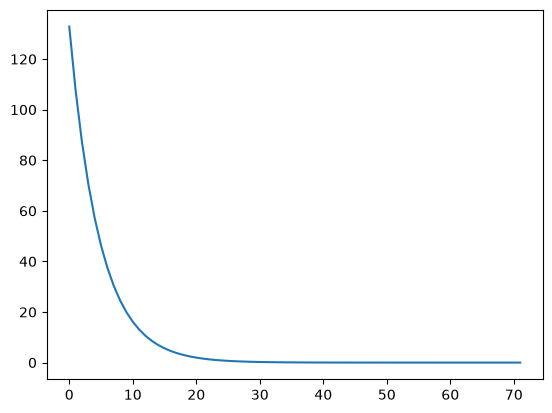

In [5]:
import matplotlib.pyplot as plt
plt.plot(L_values)
# plt.yscale('log')

Text(0.5, 0, 'Iteration')

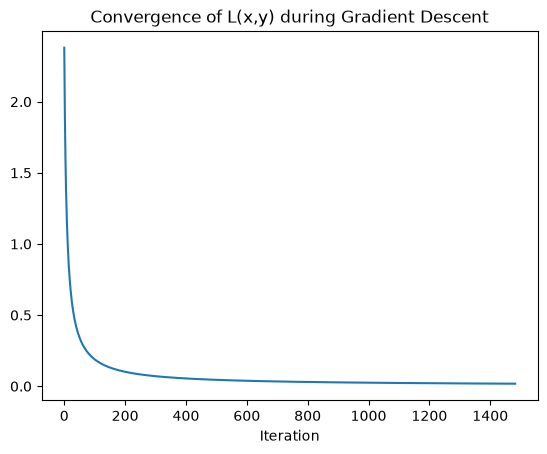

In [6]:
# the entire demo in one cell
import math
def L(x,y):
    return math.exp(x) + math.exp(y)
def dldx(x,y):
    return math.exp(x)
def dldy(x,y):
    return math.exp(y)

# Initialize parameters
x = -5
y = 1
# learning rate
eta = 0.05

# Store initial value of L
init = 1000
L_values = []

# Gradient descent loop
while abs(L(x,y)-init) > 0.00001: # iterate till convergence
    init = L(x,y)
    xnew = x - eta*dldx(x,y)
    ynew = y - eta*dldy(x,y)
    x = xnew
    y = ynew
    # print(f"x: {x:.2f}, y: {y:.2f}, L(x,y): {L(x,y):.2f}")
    L_values.append(L(x,y))
# Plotting the values of L over iterations

import matplotlib.pyplot as plt
plt.plot(L_values)
plt.title('Convergence of L(x,y) during Gradient Descent')
plt.xlabel('Iteration')

# plt.yscale('log')


Iteration 1: L(x,y) = 2.725020
Iteration 2: L(x,y) = 2.379572
Iteration 3: L(x,y) = 2.114110
Iteration 4: L(x,y) = 1.903355
Iteration 5: L(x,y) = 1.731758
Iteration 6: L(x,y) = 1.589206
Iteration 7: L(x,y) = 1.468817
Iteration 8: L(x,y) = 1.365742
Iteration 9: L(x,y) = 1.276461
Iteration 10: L(x,y) = 1.198352
Iteration 11: L(x,y) = 1.129424
Iteration 12: L(x,y) = 1.068134
Iteration 13: L(x,y) = 1.013270
Iteration 14: L(x,y) = 0.963863
Iteration 15: L(x,y) = 0.919133
Iteration 16: L(x,y) = 0.878440
Iteration 17: L(x,y) = 0.841257
Iteration 18: L(x,y) = 0.807147
Iteration 19: L(x,y) = 0.775742
Iteration 20: L(x,y) = 0.746730
Iteration 21: L(x,y) = 0.719845
Iteration 22: L(x,y) = 0.694862
Iteration 23: L(x,y) = 0.671583
Iteration 24: L(x,y) = 0.649840
Iteration 25: L(x,y) = 0.629485
Iteration 26: L(x,y) = 0.610387
Iteration 27: L(x,y) = 0.592434
Iteration 28: L(x,y) = 0.575525
Iteration 29: L(x,y) = 0.559572
Iteration 30: L(x,y) = 0.544494
Iteration 31: L(x,y) = 0.530222
Iteration 32: L(x

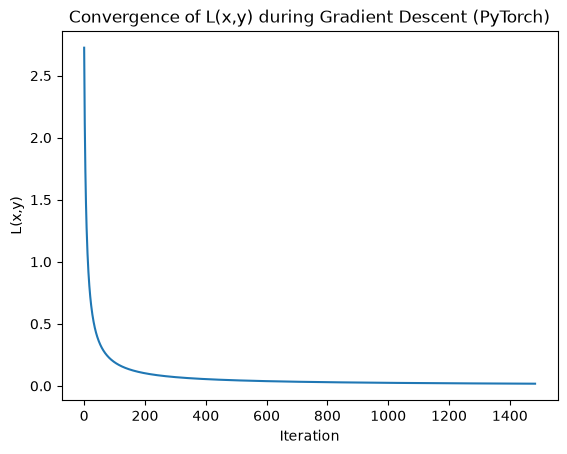

In [25]:
# the full thing but in pytorch
import torch

# Define the function L(x, y)

def L_torch(x, y):
    return torch.exp(x) + torch.exp(y)

# Initialize parameters
x = torch.tensor(-5.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

# Define the learning rate
eta = 0.05

# Store initial value of L
init = 1000

L_values = []
init = 1000

while True:
    L = L_torch(x, y)
    L_values.append(L.item())
    print(f"Iteration {len(L_values)}: L(x,y) = {L.item():.6f}")
    if abs(L.item() - init) <= 0.00001:
        break
    init = L.item()
    L.backward()
    with torch.no_grad():
        x -= eta * x.grad
        y -= eta * y.grad

    x.grad.zero_()
    y.grad.zero_()

import matplotlib.pyplot as plt
plt.plot(L_values)
plt.title('Convergence of L(x,y) during Gradient Descent (PyTorch)')
plt.xlabel('Iteration')
plt.ylabel('L(x,y)')
plt.show()

Text(0.5, 1.0, 'Convergence of L(x,y) during Gradient Descent (PyTorch SGD)')

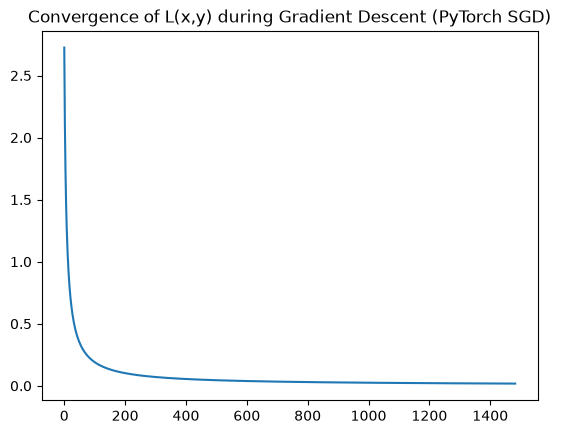

In [8]:
# use pytorch sgd for the above

import torch
import torch.optim as optim

# Define the function L(x, y)
def L_torch(x, y):
    return torch.exp(x) + torch.exp(y)

# Initialize parameters
x = torch.tensor(-5.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)
# Define the learning rate
eta = 0.05

# Create an optimizer
optimizer = optim.SGD([x, y], lr=eta)

# Store initial value of L
init = 1000
L_values = []
# Gradient descent loop
while abs(L_torch(x, y).item() - init) > 0.00001:  # iterate till convergence
    init = L_torch(x, y).item()
    optimizer.zero_grad()  # Clear gradients
    loss = L_torch(x, y)  # Compute the loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    L_values.append(loss.item())
    # print(f"x: {x.item():.2f}, y: {y.item():.2f}, L(x,y): {loss.item():.2f}")

plt.plot(L_values)
plt.title('Convergence of L(x,y) during Gradient Descent (PyTorch SGD)')

Text(0.5, 1.0, 'Convergence of L(X) during Gradient Descent (PyTorch Class)')

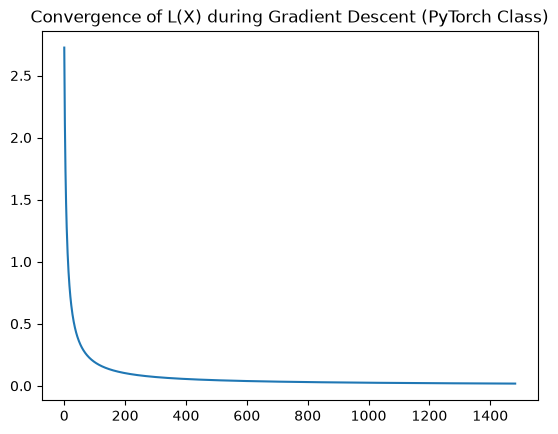

In [9]:
# idiomatic pytorch code for the above, with a class. x and y can be X, a vector of parameters, 
# and L can be a more complex function. This is just a template to show how to structure the code.

import torch

class GradientDescentOptimizer:
    def __init__(self, parameters, learning_rate):
        self.parameters = parameters
        self.learning_rate = learning_rate
        self.optimizer = torch.optim.SGD(self.parameters, lr=self.learning_rate)

    def step(self, loss):
        self.optimizer.zero_grad()  # Clear gradients
        loss.backward()  # Backpropagate to compute gradients
        self.optimizer.step()  # Update parameters

def L_torch(X):
    return torch.exp(X[0]) + torch.exp(X[1])

# Initialize parameters
X = torch.tensor([-5.0, 1.0], requires_grad=True)
# Define the learning rate
eta = 0.05

# Create an optimizer instance
optimizer = GradientDescentOptimizer([X], learning_rate=eta)
# Store initial value of L
init = 1000
L_values = []
# Gradient descent loop
while abs(L_torch(X).item() - init) > 0.00001:
    init = L_torch(X).item()
    loss = L_torch(X)  # Compute the loss
    optimizer.step(loss)  # Perform an optimization step
    L_values.append(loss.item())
    # print(f"X: {X.detach().numpy()}, L(X): {loss.item():.2f}")
plt.plot(L_values)
plt.title('Convergence of L(X) during Gradient Descent (PyTorch Class)')


In [10]:
# fit a linear regression model using pytorch
# inputs
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]])  # 5 samples, 1 feature
y = torch.tensor([[3.0], [5.0], [7.0], [9.0], [11.0]])  # 5 samples, 1 target

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # 1 input feature, 1 output

    def forward(self, x):
        return self.linear(x)
# Create model instance
model = LinearRegressionModel()
# Define loss function and optimizer
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    if (epoch) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    if loss.item() < 0.00001:
        print(f'Converged at epoch {epoch+1}')
        break

Epoch [1/10000], Loss: 114.6059
Epoch [11/10000], Loss: 0.5872
Epoch [21/10000], Loss: 0.0676
Epoch [31/10000], Loss: 0.0610
Epoch [41/10000], Loss: 0.0570
Epoch [51/10000], Loss: 0.0533
Epoch [61/10000], Loss: 0.0498
Epoch [71/10000], Loss: 0.0465
Epoch [81/10000], Loss: 0.0435
Epoch [91/10000], Loss: 0.0406
Epoch [101/10000], Loss: 0.0380
Epoch [111/10000], Loss: 0.0355
Epoch [121/10000], Loss: 0.0332
Epoch [131/10000], Loss: 0.0310
Epoch [141/10000], Loss: 0.0290
Epoch [151/10000], Loss: 0.0271
Epoch [161/10000], Loss: 0.0253
Epoch [171/10000], Loss: 0.0236
Epoch [181/10000], Loss: 0.0221
Epoch [191/10000], Loss: 0.0206
Epoch [201/10000], Loss: 0.0193
Epoch [211/10000], Loss: 0.0180
Epoch [221/10000], Loss: 0.0168
Epoch [231/10000], Loss: 0.0157
Epoch [241/10000], Loss: 0.0147
Epoch [251/10000], Loss: 0.0138
Epoch [261/10000], Loss: 0.0129
Epoch [271/10000], Loss: 0.0120
Epoch [281/10000], Loss: 0.0112
Epoch [291/10000], Loss: 0.0105
Epoch [301/10000], Loss: 0.0098
Epoch [311/10000]

In [11]:
# values of model parameters
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data.numpy()}")

linear.weight: [[2.0020454]]
linear.bias: [0.99261594]


In [12]:
import torch
# fit a linear regression model using pytorch
# inputs
X = torch.tensor([[1.0, 2.0], [2.0, 3.0], [3.0, 4.0], [4.0, 5.0], [5.0, 6.0], [10.0, 20.0]])  # 6 samples, 2 features
y = torch.tensor([[5.0], [8.0], [11.0], [14.0], [17.0], [50.0]])  # 6 samples, 1 target

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(2, 1, bias=True)  # 2 input features, 1 output

    def forward(self, x):
        return self.linear(x)
# Create model instance
model = LinearRegressionModel()
# Define loss function and optimizer
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    if (epoch) % 100 == 0:
        print(model.linear.weight.grad.norm())
        print(model.linear.bias.grad.norm())
    optimizer.step()  # Update parameters
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    if loss.item() < 0.00001:
        print(f'Converged at epoch {epoch+1}')
        break

tensor(617.9370)
tensor(45.5895)
Epoch [1/10000], Loss: 894.6306
tensor(0.0260)
tensor(0.0517)
Epoch [101/10000], Loss: 0.0019
tensor(0.0186)
tensor(0.0458)
Epoch [201/10000], Loss: 0.0016
tensor(0.0128)
tensor(0.0410)
Epoch [301/10000], Loss: 0.0014
tensor(0.0082)
tensor(0.0369)
Epoch [401/10000], Loss: 0.0013
tensor(0.0047)
tensor(0.0335)
Epoch [501/10000], Loss: 0.0011
tensor(0.0025)
tensor(0.0306)
Epoch [601/10000], Loss: 0.0010
tensor(0.0025)
tensor(0.0282)
Epoch [701/10000], Loss: 0.0009
tensor(0.0036)
tensor(0.0261)
Epoch [801/10000], Loss: 0.0009
tensor(0.0048)
tensor(0.0243)
Epoch [901/10000], Loss: 0.0008
tensor(0.0058)
tensor(0.0227)
Epoch [1001/10000], Loss: 0.0007
tensor(0.0065)
tensor(0.0213)
Epoch [1101/10000], Loss: 0.0007
tensor(0.0071)
tensor(0.0201)
Epoch [1201/10000], Loss: 0.0007
tensor(0.0075)
tensor(0.0190)
Epoch [1301/10000], Loss: 0.0006
tensor(0.0078)
tensor(0.0181)
Epoch [1401/10000], Loss: 0.0006
tensor(0.0079)
tensor(0.0172)
Epoch [1501/10000], Loss: 0.0005

In [13]:
# values of model parameters
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data.numpy()}")

linear.weight: [[0.99613935 2.001599  ]]
linear.bias: [0.00651179]


In [14]:
# calculate the value for a given x and y using the trained model
x_input = torch.tensor([[60.0, 7.0]])  # New input
model.eval()  # Set the model to evaluation mode
model_output = model(x_input)  # Get the model's prediction
print(f"Model output for input {x_input.numpy()}: {model_output.detach().numpy()}")

Model output for input [[60.  7.]]: [[73.78607]]


In [15]:
# implement linear regression using pytorch's autograd and SGD optimizer, 
# without using torch.nn.Linear or torch.nn.Module

import torch
from torch import optim

X = torch.tensor([[1.0, 2.0], [2.0, 3.0], [3.0, 4.0], [4.0, 5.0], [5.0, 6.0], [6.0, 7.0], [10.0, 20.0]])  # 7 samples, 2 features
y = torch.tensor([[5.0], [8.0], [11.0], [14.0], [17.0], [20.0], [50.0]])  # 7 samples, 1 target

class LinearRegression:
    def __init__(self):
        self.weights = torch.randn(2, 1, requires_grad=True)  # 2 input features, 1 output
        self.bias = torch.randn(1, requires_grad=True)  # Bias term

    def predict(self, x):
        return x @ self.weights + self.bias  # Linear prediction
    
model = LinearRegression()
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.SGD([model.weights, model.bias], lr=0.001)
num_epochs = 10000
for epoch in range(num_epochs):
    optimizer.zero_grad()  # Clear gradients
    outputs = model.predict(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    if (epoch) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f} parameters: {model.weights.data.numpy()} {model.bias.data.numpy()}')
    if loss.item() < 0.00001:
        print(f'Converged at epoch {epoch+1}')
        break
print(f"Weights: {model.weights.data.numpy()} Bias: {model.bias.data.numpy()}")


Epoch [1/10000], Loss: 591.9405 parameters: [[ 1.3554826 ]
 [-0.42936918]] [0.27551037]
Epoch [101/10000], Loss: 1.9357 parameters: [[2.027887 ]
 [1.3702441]] [0.28281832]
Epoch [201/10000], Loss: 1.1549 parameters: [[1.810614 ]
 [1.5075657]] [0.17664137]
Epoch [301/10000], Loss: 0.6902 parameters: [[1.6423917]
 [1.6137214]] [0.09625053]
Epoch [401/10000], Loss: 0.4136 parameters: [[1.5120242]
 [1.6958311]] [0.03569373]
Epoch [501/10000], Loss: 0.2488 parameters: [[1.4108759]
 [1.7593858]] [-0.00961801]
Epoch [601/10000], Loss: 0.1506 parameters: [[1.3322858]
 [1.8086214]] [-0.04322198]
Epoch [701/10000], Loss: 0.0920 parameters: [[1.271114 ]
 [1.8468058]] [-0.06784469]
Epoch [801/10000], Loss: 0.0569 parameters: [[1.2233971]
 [1.8764586]] [-0.08558732]
Epoch [901/10000], Loss: 0.0359 parameters: [[1.1860776]
 [1.8995239]] [-0.09806854]
Epoch [1001/10000], Loss: 0.0233 parameters: [[1.1567953]
 [1.9175013]] [-0.10653539]
Epoch [1101/10000], Loss: 0.0156 parameters: [[1.1337299]
 [1.931

In [16]:
import torch
from torch import optim

X = torch.randn(100, 2)  # 100 samples, 2 features
y = 2 * X[:, 0] ** 2 + 3 * X[:, 1] ** 3
y = y.view(-1, 1)  # Reshape to (100, 1)

class fcn(torch.nn.Module):
    def __init__(self):
        super(fcn, self).__init__()
        self.linear1 = torch.nn.Linear(2, 16)  # 2 input features, 16 outputs
        self.tanh = torch.nn.Tanh()  # Activation function
        self.linear2 = torch.nn.Linear(16, 16)  # 16 inputs from previous layer, 16 outputs
        self.linear3 = torch.nn.Linear(16, 1)  # 16 inputs from previous layer, 1 output
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.tanh(x)
        x = self.linear2(x)
        x = self.tanh(x)
        x = self.linear3(x)
        return x
    

model = fcn()
criterion = torch.nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.SGD(model.parameters(), lr=0.001)

num_epochs = 100000
for epoch in range(num_epochs):
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X)  # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()  # Backpropagate to compute gradients
    optimizer.step()  # Update parameters
    if (epoch) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        model.eval()
        model_output = model(X[0:1])  # Get the model's prediction for the first sample
        print(f"Model output for first sample: {model_output.detach().numpy()}, Actual value: {y[0:1].numpy()}")
    







Epoch [1/100000], Loss: 53.3226
Model output for first sample: [[0.11729971]], Actual value: [[-0.93982863]]
Epoch [1001/100000], Loss: 16.2872
Model output for first sample: [[-3.4022129]], Actual value: [[-0.93982863]]
Epoch [2001/100000], Loss: 5.3688
Model output for first sample: [[-1.9162322]], Actual value: [[-0.93982863]]
Epoch [3001/100000], Loss: 1.7295
Model output for first sample: [[-0.89251757]], Actual value: [[-0.93982863]]
Epoch [4001/100000], Loss: 0.8107
Model output for first sample: [[-0.7120724]], Actual value: [[-0.93982863]]
Epoch [5001/100000], Loss: 0.4418
Model output for first sample: [[-0.72613615]], Actual value: [[-0.93982863]]
Epoch [6001/100000], Loss: 0.2707
Model output for first sample: [[-0.8022846]], Actual value: [[-0.93982863]]
Epoch [7001/100000], Loss: 0.1784
Model output for first sample: [[-0.8798265]], Actual value: [[-0.93982863]]
Epoch [8001/100000], Loss: 0.1230
Model output for first sample: [[-0.9346712]], Actual value: [[-0.93982863]]


In [17]:
model.eval()
model(torch.tensor([1.0, 1.0], dtype=torch.float32))

tensor([4.9288], grad_fn=<ViewBackward0>)

In [18]:
2+3


5

In [19]:
import torch
from torch import optim

# sample CNN

class Alexnet(torch.nn.Module):
    def __init__(self):
        super(Alexnet, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 96, kernel_size=11, stride=4) # input dim = (3, 227, 227), output dim = (96, 55, 55)
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = torch.nn.Conv2d(96, 256, kernel_size=5, padding=2) # input dim = (96, 27, 27), output dim = (256, 27, 27)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(kernel_size=3, stride=2) # input dim = (256, 27, 27), output dim = (256, 13, 13)
        self.conv3 = torch.nn.Conv2d(256, 384, kernel_size=3, padding=1) # input dim = (256, 13, 13), output dim = (384, 13, 13)
        self.relu3 = torch.nn.ReLU()
        self.conv4 = torch.nn.Conv2d(384, 384, kernel_size=3, padding=1) # input dim = (384, 13, 13), output dim = (384, 13, 13)
        self.relu4 = torch.nn.ReLU()
        self.conv5 = torch.nn.Conv2d(384, 256, kernel_size=3, padding=1) # input dim = (384, 13, 13), output dim = (256, 13, 13)
        self.relu5 = torch.nn.ReLU()
        # self.pool5 = torch.nn.MaxPool2d(kernel_size=3, stride=2) # input dim = (256, 13, 13), output dim = (256, 6, 6)
        self.pool5 = torch.nn.AdaptiveAvgPool2d((6, 6))  # input dim = (256, 13, 13), output dim = (256, 6, 6)
        self.fc6 = torch.nn.Linear(256 * 6 * 6, 4096)
        self.relu6 = torch.nn.ReLU()
        self.fc7 = torch.nn.Linear(4096, 4096)
        self.relu7 = torch.nn.ReLU()
        self.fc8 = torch.nn.Linear(4096, 1000)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.conv4(x)
        x = self.relu4(x)
        x = self.conv5(x)
        x = self.relu5(x)
        x = self.pool5(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc6(x)
        x = self.relu6(x)
        x = self.fc7(x)
        x = self.relu7(x)
        x = self.fc8(x)
        return x
    

model = Alexnet()
# number of parameters in the model
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")



Number of parameters in the model: 62378344


In [20]:
# model summary
print(model)

Alexnet(
  (conv1): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (conv4): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (conv5): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu5): ReLU()
  (pool5): AdaptiveAvgPool2d(output_size=(6, 6))
  (fc6): Linear(in_features=9216, out_features=4096, bias=True)
  (relu6): ReLU()
  (fc7): Linear(in_features=4096, out_features=4096, bias=True)
  (relu7): ReLU()
  (fc8): Linear(in_features=4096, out_features=1000, bias=True)
)


In [21]:
# load data and labels
# folder d:\examples

X = torch.randn(100, 3, 224, 224)  # 100 samples, 3 channels, 224x224 images
y = torch.randint(0, 1000, (100,))  # 100 samples, random labels between 0 and 999

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# training loop

epochs = 10
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [1/10], Loss: 6.9094
Epoch [2/10], Loss: 6.9092
Epoch [3/10], Loss: 6.9090
Epoch [4/10], Loss: 6.9089
Epoch [5/10], Loss: 6.9087
Epoch [6/10], Loss: 6.9085
Epoch [7/10], Loss: 6.9083
Epoch [8/10], Loss: 6.9081
Epoch [9/10], Loss: 6.9079
Epoch [10/10], Loss: 6.9077


In [22]:
# classic resnet

import torch
from torch import nn, optim

class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.downsample = None

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(identity)
        out += identity
        out = self.relu(out)
        return out
    
class ResNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        layers.append(ResNetBlock(in_channels, out_channels))
        for _ in range(1, blocks):
            layers.append(ResNetBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # Flatten the tensor
        x = self.fc(x)
        return x
    
